<a href="https://colab.research.google.com/github/PW-ue-kat/wizualizacja/blob/cw3/zadanie3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0,11,22


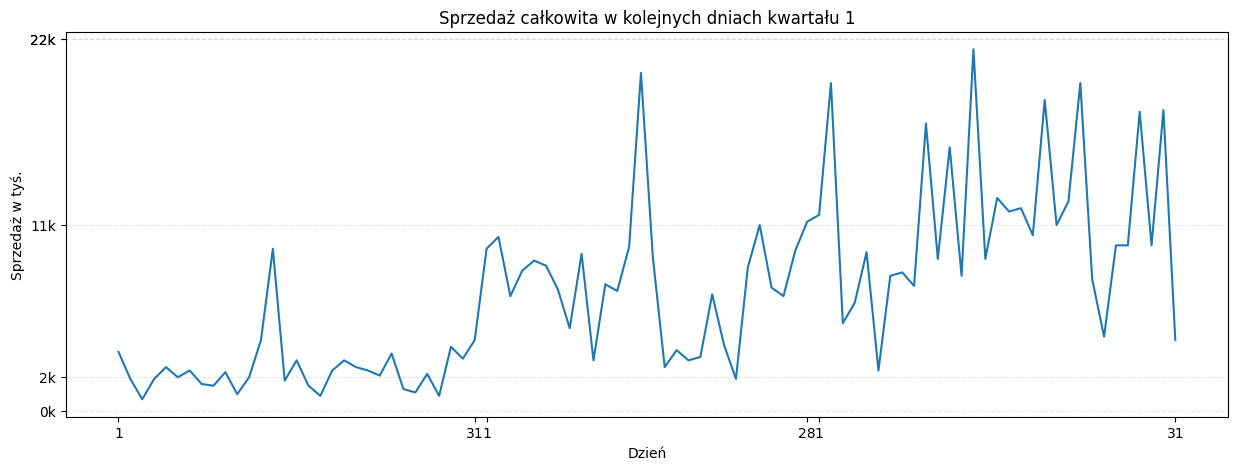

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor, ceil


dane_zrodlowe = pd.read_csv('dane.csv', sep=';', decimal = ',', index_col=0)
dane_zrodlowe['sprzedaz_calkowita'] = dane_zrodlowe['prodA']+dane_zrodlowe['prodB']

#dane_zrodlowe.head()

sprzedaz = dane_zrodlowe.drop(['prodA', 'prodB'], axis = 1)

sprzedaz['mies_cat'] = pd.Categorical(sprzedaz.Miesiac,
                      categories=["styczen","luty","marzec"],
                      ordered=True)

sprzedaz.sort_values(['mies_cat', 'dzien'], inplace = True, ignore_index = True)
sprzedaz['data_sprzedazy'] = sprzedaz['mies_cat'].astype(str) + " " + sprzedaz['dzien'].astype(str)
sprzedaz.head()

# rysowanie wykresu
#środkowa linia -  dokładnie środek
# górna linia - max -2k
# dolna linia - min zaokrąglony w dół

s_min = floor(sprzedaz['sprzedaz_calkowita'].min())
s_avg = sprzedaz['sprzedaz_calkowita'].mean()

s_max = ceil(sprzedaz['sprzedaz_calkowita'].max())
s_half = int(((s_max-s_min)/2)+s_min)
print(f"{s_min},{s_half},{s_max}")

skala_y = [s_min, s_min+2, s_half, s_max, s_max]
s_etykiety = [f'{t}k' for t in skala_y]

fig, ax = plt.subplots(figsize = [15,5])
sprzedaz['sprzedaz_calkowita'].plot(
    xlabel="Dzień",
    ylabel="Sprzedaż w tyś.",
    title="Sprzedaż całkowita w kolejnych dniach kwartału 1"
)
ax.set_yticks(skala_y)
ax.set_yticklabels(s_etykiety)
ax.set_xticks([0,30,31,58,59,89],[1,31,1,28,1,31])
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()



